In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
data = { 'SqFt': [1500, 1800, 2400, 3000, 3500, 4000, 4500, 5000],
         'Price': [300000, 350000, 450000, 500000, 580000, 650000, 720000, 800000]}
df = pd.DataFrame(data)

In [3]:
X = df[['SqFt']] 
y = df['Price']

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

In [5]:
model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [6]:
y_pred = model.predict(X_test)

In [7]:
print(f"Intercept (B0): {model.intercept_}")
print(f"Slope (B1): {model.coef_[0]}")

Intercept (B0): 94779.62781586673
Slope (B1): 139.76493633692462


In [8]:
print(f"MAE: {mean_absolute_error(y_test, y_pred)}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred))}")
print(f"R2 Score: {r2_score(y_test, y_pred)}")

MAE: 3741.429970617057
RMSE: 3742.7117300262953
R2 Score: 0.9993774270624854


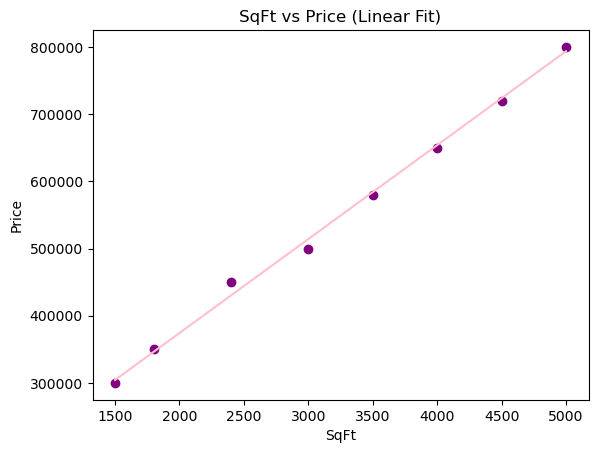

In [9]:
plt.scatter(X, y, color='purple') # Actual data
plt.plot(X, model.predict(X), color='pink') # Regression line
plt.xlabel('SqFt')
plt.ylabel('Price')
plt.title('SqFt vs Price (Linear Fit)')
plt.show()

In [10]:
new_sqft = [[2800]] 
predicted_price = model.predict(new_sqft)

print(f"The predicted price for the 2800 SqFt is: {predicted_price[0]}")

The predicted price for the 2800 SqFt is: 486121.4495592557


D:\Anaconda-navigator\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [22]:
data2 = {
'RD_Spend': [165349, 162597, 153441, 144372, 142107, 131876, 134615],
'Admin_Spend': [136897, 151377, 101145, 118671, 91391, 99814, 147198],
'Marketing_Spend': [471784, 443898, 407934, 383199, 366168, 362861, 127716],
'Profit': [192261, 191792, 191050, 182901, 166187, 156991, 156122]
}
df2 = pd.DataFrame(data2)
print("Profit prediction dataset: ")
print(df2)
print()

Profit prediction dataset: 
   RD_Spend  Admin_Spend  Marketing_Spend  Profit
0    165349       136897           471784  192261
1    162597       151377           443898  191792
2    153441       101145           407934  191050
3    144372       118671           383199  182901
4    142107        91391           366168  166187
5    131876        99814           362861  156991
6    134615       147198           127716  156122



In [13]:
X = df2[['RD_Spend', 'Admin_Spend', 'Marketing_Spend']]
Y = df2['Profit']

In [18]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)
print(f"Training samples: {len(X_train)}")
print(f"Testing samples: {len(X_test)}")
print()

Training samples: 5
Testing samples: 2



In [16]:
model2 = LinearRegression()
model2.fit(X_train, Y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [24]:
intercept = model2.intercept_
coefficients = model2.coef_
print("Multiple Linear Regression Equation:")
print(f"Profit = {intercept:.4f}")
print(f" + {coefficients[0]:.4f} x RD_Spend")
print(f" + {coefficients[1]:.4f} x Admin_Spend")
print(f" + {coefficients[2]:.4f} x Marketing_Spend")
print()


Multiple Linear Regression Equation:
Profit = -99847.3812
 + 1.3308 x RD_Spend
 + 0.4310 x Admin_Spend
 + 0.1042 x Marketing_Spend



Based on the regression coefficient, RD_Spend has the highest positive impact on the Profit. As, it has the largest coefficient value among the all three coefficients.

In [31]:
Y_test_pred = model2.predict(X_test)
r2 = r2_score(Y_test, Y_test_pred)
print(f"R2 Score : {r2:>10.4f} ({r2*100:>5.4f}% variance explained)")
print()

R2 Score : -23824.9413 (-2382494.1252% variance explained)



As the value of R2 Score is in negative, the model's performance is worst.

In [72]:
df = pd.read_csv('Student_Performance.csv')
df = pd.get_dummies(df, drop_first=True)

In [73]:
X = df[['Hours Studied','Previous Scores','Extracurricular Activities_Yes','Sleep Hours','Sample Question Papers Practiced']]
y = df['Performance Index']

In [75]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [76]:
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [77]:
print(f"Slope (B1) Hours Studied: {model.coef_[0]}")
print(f"Slope (B1) Previous Scores: {model.coef_[1]}")
print(f"Slope (B1) Extracurricular Activities: {model.coef_[2]}")
print(f"Slope (B1) Sleep Hours: {model.coef_[3]}")
print(f"Slope (B1) Sample Question Papers Practiced: {model.coef_[4]}")

Slope (B1) Hours Studied: 2.852483930072595
Slope (B1) Previous Scores: 1.01698819893293
Slope (B1) Extracurricular Activities: 0.6086166795764202
Slope (B1) Sleep Hours: 0.47694148417627313
Slope (B1) Sample Question Papers Practiced: 0.1918314414505426


In [79]:
print(f"\nMAE: {mean_absolute_error(y_test, y_pred)}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred))}")
print(f"R2 Score: {r2_score(y_test, y_pred)}")


MAE: 1.6111213463123053
RMSE: 2.020551508505007
R2 Score: 0.9889832909573145


The model explains 98% of the variation in student performance, indicating a strong relationship between study patterns and performance index.

The RMSE is higher than MAE, indicating the presence of some large prediction errors.

Students should focus more on sleep, as it has the strong positive impact on performance.

Question: If your MAE is 5,000 and your RMSE is 12,000, what does that tell you
about your model's errors?

This indicates that while average errors are moderate, some predictions have very large errors. RMSE is much higher because it penalizes large errors more heavily.

Question : If the R2 score is 0.45, is this model reliable for making business decisions?
Why or why not?

The model explains only 45% of the variation in the data, which is relatively low. Therefore, it may not be reliable for making important decisions without further improvement.